In [16]:
import importlib
import Multiclass_functions_1

import torch
from torch import nn, optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from Multiclass_functions_1 import * # import all functions
DEVICE = "mps" if torch.mps.is_available() else "cpu"

In [17]:
importlib.reload(Multiclass_functions_1)
from Multiclass_functions_1 import * 

In [18]:
BATCH_SIZE = 32
LR = 1e-3
EPOCH = 20
criterion = nn.CrossEntropyLoss()
new_model_train = True
model_type = "CNN_deep"
dataset = "STL10"
save_model_path = f'/Volumes/김상현/results/MC_STL10/{model_type}_{dataset}.pt'

In [ ]:
transform = transforms.ToTensor()
train_DS = datasets.STL10(root = '/Volumes/김상현/dataset', split = "train", download = False, transform = transform)
test_DS = datasets.STL10(root = '/Volumes/김상현/dataset', split = "test", download = False, transform = transform)
train_DL = torch.utils.data.DataLoader(train_DS, batch_size=BATCH_SIZE, shuffle=True)
test_DL = torch.utils.data.DataLoader(test_DS, batch_size=BATCH_SIZE, shuffle=True)

100.0%


In [12]:
print("Information of train dataset")
print(train_DS)
print("Information of test dataset")
print(test_DS)
print(f"Size of train dataset {len(train_DS)}")
print(f"Size of test dataset {len(test_DS)}")

Information of train dataset
Dataset STL10
    Number of datapoints: 5000
    Root location: /Volumes/김상현/dataset
    Split: train
    StandardTransform
Transform: ToTensor()
Information of test dataset
Dataset STL10
    Number of datapoints: 8000
    Root location: /Volumes/김상현/dataset
    Split: test
    StandardTransform
Transform: ToTensor()
Size of train dataset 5000
Size of test dataset 8000


['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']
torch.Size([32, 3, 96, 96])
bird


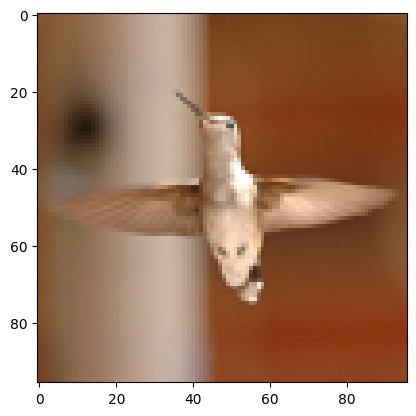

In [15]:
print(test_DS.classes)
x_batch, y_batch = next(iter(test_DL))
print(x_batch.shape)
plt.imshow(x_batch[0].permute(1,2,0))
print(test_DS.classes[y_batch[0]])

In [24]:
class CNN_deep(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_block1 = nn.Sequential(nn.Conv2d(3,32,3,padding=1),
                                         nn.BatchNorm2d(32),
                                         nn.ReLU(),
                                         nn.Conv2d(32,32,3,padding=1),
                                         nn.BatchNorm2d(32),
                                         nn.ReLU())
        self.Maxpool1 = nn.MaxPool2d(2)

        self.conv_block2 = nn.Sequential(nn.Conv2d(32,64,3,padding=1),
                                         nn.BatchNorm2d(64),
                                         nn.ReLU(),
                                         nn.Conv2d(64,64,3,padding=1),
                                         nn.BatchNorm2d(64),
                                         nn.ReLU(),
                                         nn.Conv2d(64,64,3,padding=1),
                                         nn.BatchNorm2d(64),
                                         nn.ReLU())
        self.Maxpool2 = nn.MaxPool2d(2)

        self.conv_block3 = nn.Sequential(nn.Conv2d(64,128,3,padding=1),
                                         nn.BatchNorm2d(128),
                                         nn.ReLU(),
                                         nn.Conv2d(128,128,3,padding=1),
                                         nn.BatchNorm2d(128),
                                         nn.ReLU(),
                                         nn.Conv2d(128,128,3,padding=1),
                                         nn.BatchNorm2d(128),
                                         nn.ReLU())
        self.Maxpool3 = nn.MaxPool2d(2)
        
        # self.classifier = nn.Sequential(nn.Linear(128*4*4,512),
        #                                 nn.Linear(512,10))
        self.classifier = nn.Sequential(nn.Linear(128*12*12,512),
                                        nn.Linear(512,10))    
        
    def forward(self, x):
        x = self.conv_block1(x)
        x = self.Maxpool1(x)
        x = self.conv_block2(x)
        x = self.Maxpool2(x)
        x = self.conv_block3(x)
        x = self.Maxpool3(x)
        # x = torch.flatten(x, start_dim=1) # !!!!!!!
        # x = self.classifier(x)
        x = torch.flatten(x, start_dim=1) # !!!!!!!
        x = self.classifier(x)
        return x

In [25]:
exec(f"model = {model_type}().to(DEVICE)")
print(model)
x_batch, _ = next(iter(train_DL))
print(model(x_batch.to(DEVICE)).shape)

CNN_deep(
  (conv_block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
  )
  (Maxpool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv_block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): BatchNorm2d(64, eps=1e-05, momentum=

Epoch: 1, train loss: 5.128
Train Accuaracy: 930/5000 (18.6%)
--------------------
Epoch: 2, train loss: 1.876
Train Accuaracy: 1678/5000 (33.6%)
--------------------
Epoch: 3, train loss: 1.595
Train Accuaracy: 2060/5000 (41.2%)
--------------------
Epoch: 4, train loss: 1.445
Train Accuaracy: 2316/5000 (46.3%)
--------------------
Epoch: 5, train loss: 1.318
Train Accuaracy: 2532/5000 (50.6%)
--------------------
Epoch: 6, train loss: 1.274
Train Accuaracy: 2685/5000 (53.7%)
--------------------
Epoch: 7, train loss: 1.195
Train Accuaracy: 2846/5000 (56.9%)
--------------------
Epoch: 8, train loss: 1.092
Train Accuaracy: 2982/5000 (59.6%)
--------------------
Epoch: 9, train loss: 1.038
Train Accuaracy: 3140/5000 (62.8%)
--------------------
Epoch: 10, train loss: 0.978
Train Accuaracy: 3252/5000 (65.0%)
--------------------
Epoch: 11, train loss: 0.898
Train Accuaracy: 3384/5000 (67.7%)
--------------------
Epoch: 12, train loss: 0.82
Train Accuaracy: 3536/5000 (70.7%)
------------

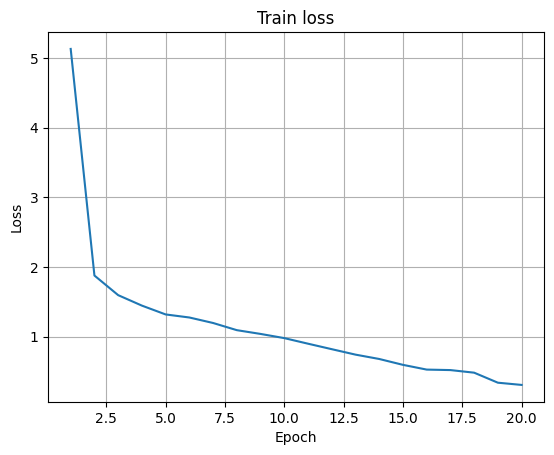

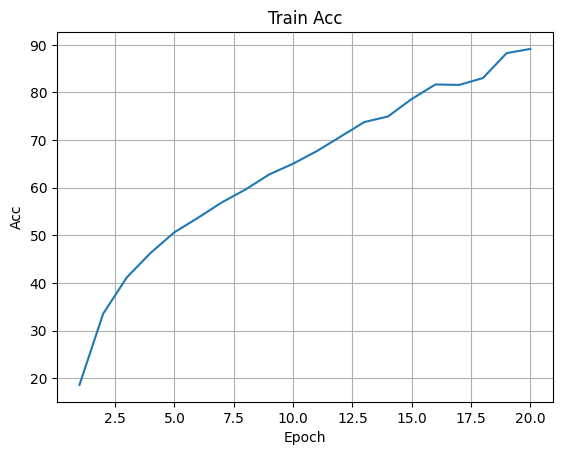

In [26]:
if new_model_train:
    optimizer = optim.Adam(model.parameters(), lr = LR)
    loss_history, acc_history = Train(model, train_DL, criterion, optimizer, EPOCH)
    
    torch.save(model, save_model_path)

    plt.plot(range(1, EPOCH + 1), loss_history)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title("Train loss")
    plt.grid()
    plt.show()
    
    
    plt.plot(range(1, EPOCH + 1), acc_history)
    plt.xlabel('Epoch')
    plt.ylabel('Acc')
    plt.title('Train Acc')
    plt.grid()
    plt.show()

In [27]:
load_model = torch.load(save_model_path, map_location=DEVICE, weights_only=False)

In [28]:
Test(load_model ,test_DL)
print(count_params(load_model))

Test Accuaracy: 4728/8000 (59.1%)
9915626


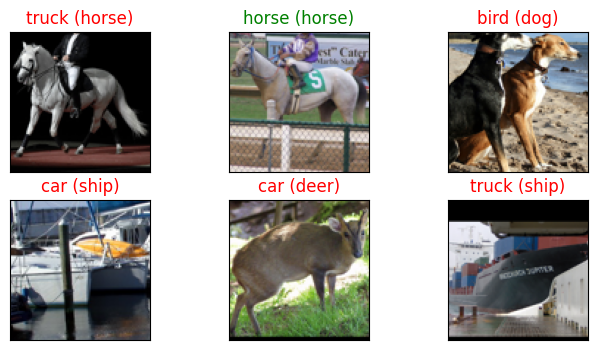

In [36]:
Test_plot(load_model, test_DL)